# 4. 実施内容（個人ワーク）— サンプル時系列（CSV）の解析

原系列 $y_n$ と 1 次階差系列 $\Delta y_n = y_n - y_{n-1}$ について，以下を実施する。

| 項目 | 内容 |
|---|---|
| **(a)** | $y_n$ と $\Delta y_n$ のグラフ |
| **(b)** | $\Delta y_n$ の ADF 検定 + AIC 最小化による AR($p$) モデルの構築 |
| **(c)** | AR モデルの残差とその PARCOR |
| **(d)** | カルマンフィルタ（AR モデル）による長期予測 |

**使用データ**: GitHub `data/Practice02_01_2026+1.csv`（新潟県信濃川・長岡観測所，2025年7月20日〜8月1日，水位 [m]）

---
### 時系列分析法
- **モデルの種類**: AR（自己回帰）モデル（定数項付き）＋ カルマンフィルタ（状態空間表現）
- **次数決定法**: AIC（赤池情報量規準）最小化
- **定常性検定**: ADF（Augmented Dickey-Fuller）検定（有意水準 5%）
- **モデルパラメータ**: $a_0$（定数項），$a_1,\ldots,a_p$（AR 係数），$\sigma^2$（システムノイズ分散）

カルマンフィルタの行列は `example02_04.ipynb` と同一の同伴形（companion form）を使用:

$$
\boldsymbol{F} = \begin{pmatrix} a_1 & 1 & \cdots & 0 & 0 \\ a_2 & 0 & \ddots & 0 & 0 \\ \vdots & \vdots & \ddots & 1 & 0 \\ a_p & 0 & \cdots & 0 & 0 \\ 0 & 0 & \cdots & 0 & 1 \end{pmatrix},\quad
\boldsymbol{G} = \begin{pmatrix}1\\0\\\vdots\\0\\0\end{pmatrix},\quad
\boldsymbol{H} = \begin{pmatrix}1 & 0 & \cdots & 0 & 1\end{pmatrix}
$$

## 準備

In [13]:
!pip install -q japanize-matplotlib statsmodels pykalman
%matplotlib inline

import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import japanize_matplotlib
sns.set(font="IPAexGothic")

# 共通フォントサイズ設定
plt.rcParams.update({
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

## データ取得

In [14]:
import os, urllib.request

# GitHub の raw URL（直接ダウンロード用）
CSV_URL_RAW = (
    "https://raw.githubusercontent.com/takenoko888/sorcecode_4/master/"
    "data/Practice02_01_2026%2B1.csv"
)
CSV_PATH = "Practice02_01_2026+1.csv"

def _ensure_csv(path, url):
    """ファイルが存在しない / HTML が混入している場合のみダウンロードする。"""
    need = True
    if os.path.isfile(path):
        with open(path, "r", encoding="utf-8") as f:
            head = f.readline().strip().lower()
        if "," in head and "html" not in head:
            need = False
    if need:
        urllib.request.urlretrieve(url, path)
        print("ダウンロード完了:", path)
    else:
        print("既存ファイルを使用:", path)

_ensure_csv(CSV_PATH, CSV_URL_RAW)

既存ファイルを使用: Practice02_01_2026+1.csv


## 系列の作成

In [15]:
df = pd.read_csv(CSV_PATH)
df["t"] = pd.to_datetime(df["t"])
df = df.sort_values("t").reset_index(drop=True)

# 欠損補間（前値補完）
df["y_fill"] = df["y"].fillna(method="ffill").astype(float)

t  = df["t"].to_numpy()            # 時刻配列
y  = df["y_fill"].to_numpy()       # 原系列
dy = np.diff(y)                     # 1次階差系列

print(f"データ件数 : {len(y)} 点")
print(f"階差系列   : {len(dy)} 点")
print(f"期間       : {df['t'].iloc[0]}  〜  {df['t'].iloc[-1]}")
print("先頭5行:")
display(df.head())

データ件数 : 311 点
階差系列   : 310 点
期間       : 2025-07-20 00:00:00+09:00  〜  2025-08-01 22:00:00+09:00
先頭5行:


,t,y,y_fill
0,2025-07-20 00:00:00+09:00,15.72,15.72
1,2025-07-20 01:00:00+09:00,15.72,15.72
2,2025-07-20 02:00:00+09:00,15.72,15.72
3,2025-07-20 03:00:00+09:00,15.72,15.72
4,2025-07-20 04:00:00+09:00,15.72,15.72


## 訓練／テスト分割

テストデータ割合 `testdataratio = 0.2`（後ろ 20%）

In [16]:
testdataratio = 0.2
ntest  = int(np.ceil(testdataratio * len(dy)))
ntrain = len(dy) - ntest

dy_train = dy[:ntrain]
dy_test  = dy[ntrain:]

print(f"訓練データ : {ntrain} 点  /  テストデータ : {ntest} 点")

訓練データ : 248 点  /  テストデータ : 62 点


---
## (a) 原系列 $y_n$ と 1 次階差系列 $\Delta y_n$ のグラフ

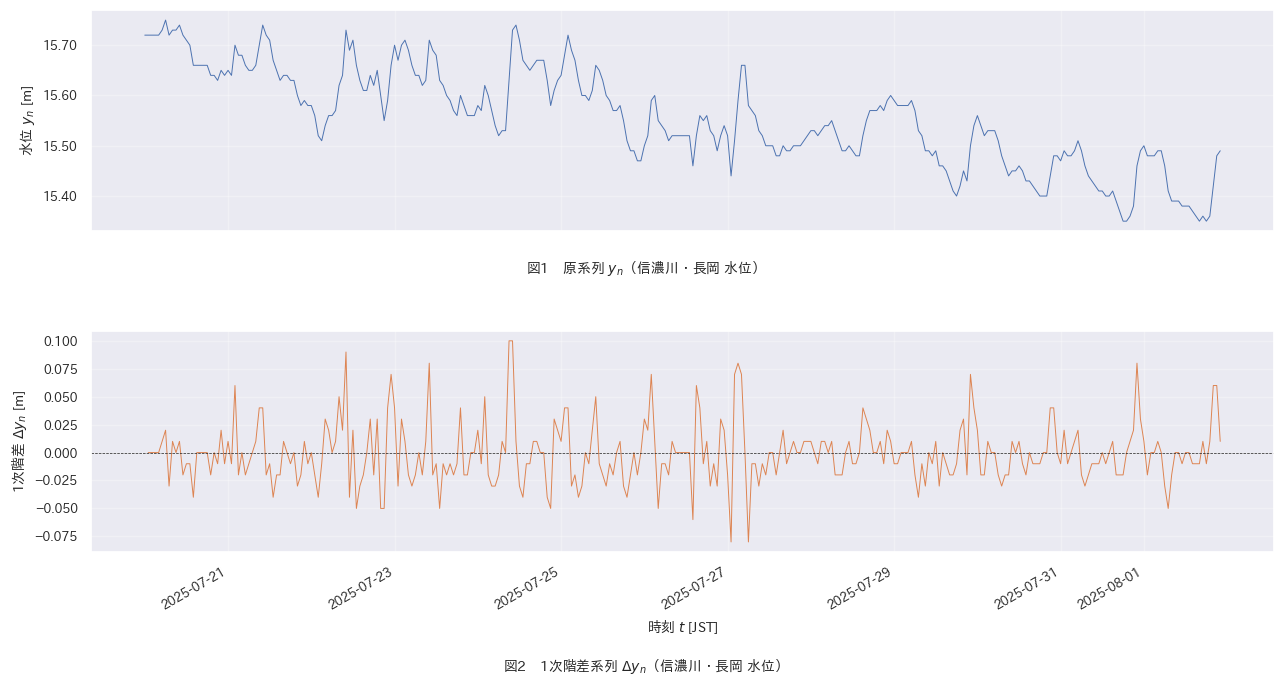

In [ ]:
# ── 図1: 原系列 ──
fig1, ax1 = plt.subplots(figsize=(13, 4.0))
ax1.plot(t, y, lw=0.7, color="C0")
ax1.set_xlabel("時刻 $t$ [JST]")
ax1.set_ylabel("水位 $y_n$ [m]")
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

fig1.autofmt_xdate(rotation=30, ha="right")
fig1.tight_layout()
fig1.subplots_adjust(bottom=0.22)
fig1.text(
    0.5, 0.02,
    "図1　原系列 $y_n$（信濃川・長岡 水位）",
    ha="center", va="bottom", fontsize=10
 )
plt.show()

# ── 図2: 階差系列 ──
fig2, ax2 = plt.subplots(figsize=(13, 4.0))
ax2.plot(t[1:], dy, lw=0.7, color="C1")
ax2.set_xlabel("時刻 $t$ [JST]")
ax2.set_ylabel("1次階差 $\\Delta y_n$ [m]")
ax2.axhline(0, color="k", lw=0.5, ls="--")
ax2.grid(True, alpha=0.3)

fig2.autofmt_xdate(rotation=30, ha="right")
fig2.tight_layout()
fig2.subplots_adjust(bottom=0.22)
fig2.text(
    0.5, 0.02,
    "図2　1次階差系列 $\\Delta y_n$（信濃川・長岡 水位）",
    ha="center", va="bottom", fontsize=10
 )
plt.show()

---
## (b) $\Delta y_n$ の ADF 検定と AR($p$) モデル（AIC 最小化）

### 使用手法
- **定常性検定**: ADF（Augmented Dickey-Fuller）検定（帰無仮説: 単位根過程，有意水準 5%）
- **次数決定**: `ar_model.ar_select_order`（`ic='aic'`）による AIC 最小化
- **モデル**: 定数項付き AR($p$)  $\;\Delta y_n = a_0 + \sum_{k=1}^{p} a_k \Delta y_{n-k} + w_n,\quad w_n \sim \mathcal{N}(0,\sigma^2)$

In [18]:
import statsmodels.api as sm
from statsmodels.tsa import ar_model, stattools

# ── ADF 検定 ──
adf_stat, adf_p, adf_lag, adf_nobs, adf_crit, _ = stattools.adfuller(dy_train)

print("=" * 55)
print("  ADF 検定結果（訓練区間の Δy）")
print("=" * 55)
print(f"  検定統計量  : {adf_stat:.6g}")
print(f"  p 値        : {adf_p:.6g}")
print(f"  使用ラグ数  : {adf_lag}")
print(f"  有効観測数  : {adf_nobs}")
for lv, cv in adf_crit.items():
    print(f"  臨界値 {lv}  : {cv:.4f}")
print()
if adf_p <= 0.05:
    print("  → p 値 ≤ 0.05：単位根仮説を棄却 → Δy は定常とみなせる ✔")
else:
    print("  → 警告: p 値 > 0.05，定常性を確認できません。")
print("=" * 55)

# ── AR 次数選択（AIC 最小化）──
maxlag = min(50, max(5, ntrain // 10))
sel = ar_model.ar_select_order(dy_train, maxlag=maxlag, ic="aic", trend="c")
ords_sel = sel.ar_lags
popt = int(max(ords_sel))

# 同伴形（連続ラグ 1..p）への統一
if tuple(ords_sel) != tuple(range(1, popt + 1)):
    print(f"\nAIC 選択ラグ {ords_sel} → 同伴形のため連続 AR(1..{popt}) に再推定")
    results = ar_model.AutoReg(dy_train, lags=popt, trend="c").fit()
else:
    results = ar_model.AutoReg(dy_train, lags=ords_sel, trend="c").fit()

print(f"\nAR 次数  p  = {popt}")
print(f"AIC          = {results.aic:.4f}")
print(f"sigma²       = {results.sigma2:.6g}")
print()

# パラメータ一覧
param_names = ["a₀ (定数)"] + [f"a{k}" for k in range(1, popt + 1)]
params_df = pd.DataFrame(
    {"パラメータ": param_names, "推定値": results.params}
)
print("AR(p) モデルパラメータ")
display(params_df)

print("\n--- 推定サマリ ---")
print(results.summary())

  ADF 検定結果（訓練区間の Δy）
  検定統計量  : -8.58079
  p 値        : 7.73874e-14
  使用ラグ数  : 5
  有効観測数  : 242
  臨界値 1%  : -3.4577
  臨界値 5%  : -2.8736
  臨界値 10%  : -2.5732

  → p 値 ≤ 0.05：単位根仮説を棄却 → Δy は定常とみなせる ✔

AR 次数  p  = 24
AIC          = -969.4122
sigma²       = 0.000612628

AR(p) モデルパラメータ


,パラメータ,推定値
0,a₀ (定数),-0.002122
1,a1,0.149676
2,a2,-0.111195
3,a3,-0.182345
4,a4,-0.095519
5,a5,-0.058587
6,a6,-0.163519
7,a7,0.024705
8,a8,-0.126036
9,a9,-0.112224



--- 推定サマリ ---
                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  248
Model:                    AutoReg(24)   Log Likelihood                 510.706
Method:               Conditional MLE   S.D. of innovations              0.025
Date:                Tue, 19 May 2026   AIC                           -969.412
Time:                        06:21:56   BIC                           -880.709
Sample:                            24   HQIC                          -933.607
                                  248                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0021      0.002     -1.221      0.222      -0.006       0.001
y.L1           0.1497      0.065      2.307      0.021       0.022       0.277
y.L2          -0.1112      0.065     

---
## (c) AR モデルの残差とその PARCOR

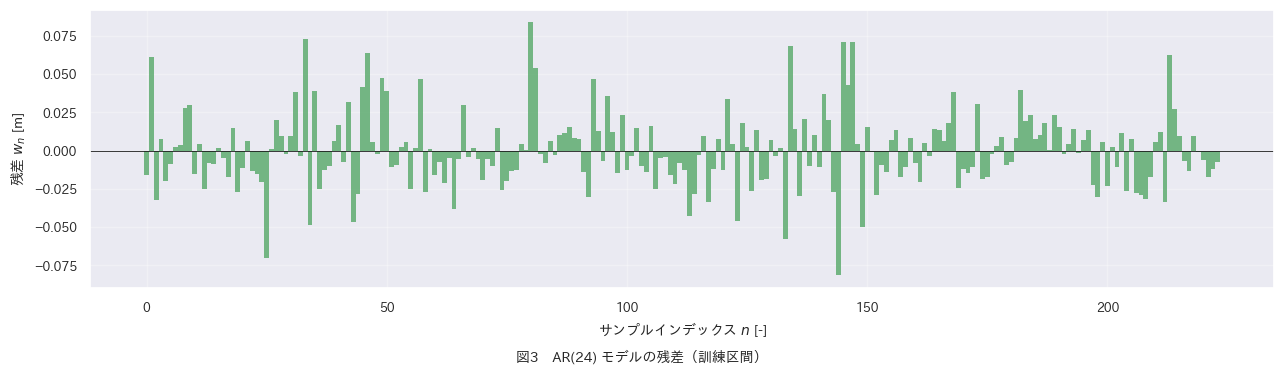

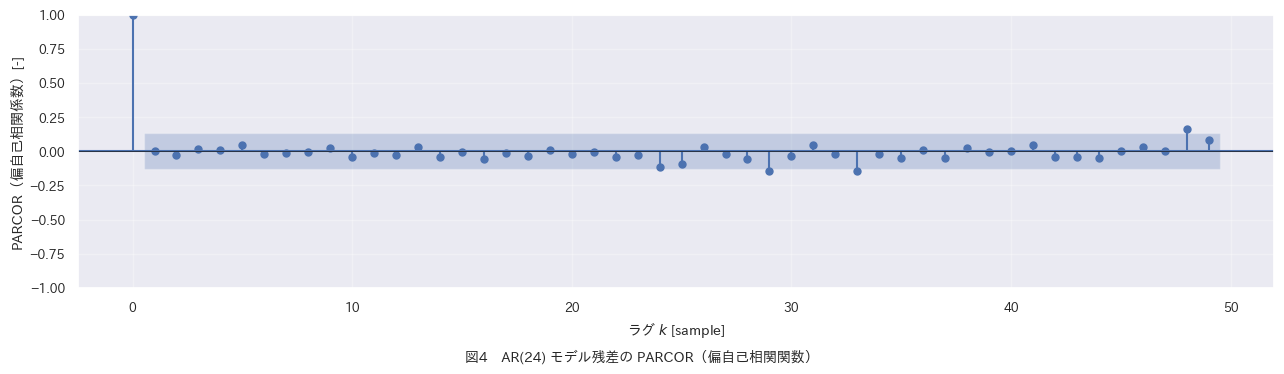

In [19]:
residual = results.resid
maxlag_plot = min(80, max(10, ntrain // 5))

# ── 図3: 残差 ──
fig, ax = plt.subplots(figsize=(13, 3.8))
ax.bar(np.arange(len(residual)), residual, width=1.0,
       color="C2", edgecolor="none", alpha=0.8)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("サンプルインデックス $n$ [-]")
ax.set_ylabel("残差 $w_n$ [m]")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)
fig.text(0.5, 0.02,
         f"図3　AR({popt}) モデルの残差（訓練区間）",
         ha="center", va="bottom", fontsize=10)
plt.show()

# ── 図4: 残差の PARCOR ──
resid_clean = pd.Series(residual).dropna()
fig_pacf = sm.graphics.tsa.plot_pacf(
    resid_clean, lags=maxlag_plot, method="ywm",
    title=""   # タイトルは下に付けるため空文字
)
fig_pacf.set_size_inches(13, 3.8)
fig_pacf.axes[0].set_xlabel("ラグ $k$ [sample]")
fig_pacf.axes[0].set_ylabel("PARCOR（偏自己相関係数）[-]")
fig_pacf.axes[0].axhline(0, color="k", lw=0.5)
fig_pacf.axes[0].grid(True, alpha=0.3)
fig_pacf.tight_layout()
fig_pacf.subplots_adjust(bottom=0.22)
fig_pacf.text(0.5, 0.02,
              f"図4　AR({popt}) モデル残差の PARCOR（偏自己相関関数）",
              ha="center", va="bottom", fontsize=10)
plt.show()

---
## (d) カルマンフィルタ（AR モデル）による推定・予測・長期予測

### カルマンフィルタのモデルパラメータ

| 記号 | 内容 | 値 |
|---|---|---|
| $\boldsymbol{F}$ | 状態推移行列（同伴形）| AR 係数から構成 |
| $\boldsymbol{G}$ | システムノイズ入力行列 | $[1,0,\ldots,0]^T$ |
| $\boldsymbol{H}$ | 観測行列 | $[1,0,\ldots,0,1]$ |
| $Q$ | システムノイズ分散 | $\sigma^2$（AR 残差分散）|
| $R$ | 観測ノイズ分散 | $0$（完全観測を仮定）|

- 訓練区間: `kf.filter()` によるフィルタ推定
- テスト区間 + 長期: `kf.filter_update(observation=None)` による 1 期先予測を繰り返す

In [20]:
from pykalman import KalmanFilter

# ── カルマンフィルタ行列の構築（example02_04.ipynb と同一） ──
n_dim_state = popt + 1  # AR 係数 p 個 ＋ 定数項 1 個
ar_const = float(results.params[0])
ar_coefs = np.asarray(results.params[1:], dtype=float).ravel()

# 推移行列 F（同伴形）
f1 = ar_coefs.reshape(-1, 1)         # AR係数列（上半部左列）
f2 = np.eye(popt); f2[-1, -1] = 0.   # シフト行列
f3 = np.zeros((1, n_dim_state)); f3[-1, -1] = 1.  # 定数行
F = np.block([[f1, f2], [f3]])

# 係数行列 G
G = np.zeros((n_dim_state, 1)); G[0, 0] = 1.

# 観測行列 H
H = np.zeros((1, n_dim_state)); H[0, 0] = 1.; H[0, -1] = 1.

# ノイズ分散
Q = results.sigma2  # システムノイズ
R = 0.              # 観測ノイズ（完全観測）

print(f"状態次元 n_dim_state = {n_dim_state}  ( p={popt} + 定数 )")
print(f"Q (sigma²) = {Q:.6g}")
print("F =\n", F)
print("G =\n", G.T, "  (転置表示)")
print("H =\n", H)

# ── カルマンフィルタ生成 ──
kf = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=n_dim_state,
    initial_state_mean=ar_const * np.ones(n_dim_state),
    initial_state_covariance=np.eye(n_dim_state),
    transition_matrices=F,
    observation_matrices=H,
    observation_covariance=R,
    transition_covariance=G.dot(Q).dot(G.T),
)

状態次元 n_dim_state = 25  ( p=24 + 定数 )
Q (sigma²) = 0.000612628
F =
 [[ 0.14967628  1.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [-0.11119474  0.          1.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [-0.18234547  0.          0.          1.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [-0.09551866  0.          0.          0.          1.          0.
   0.          0.          0. 

In [ ]:
# ── 訓練区間: フィルタ推定 ──
filtered_means, filtered_covs = kf.filter(dy_train)
dy_kf_fit = filtered_means.dot(H.T).ravel()  # フィルタ推定値

# ── テスト区間: 1期先予測 ──
cur_state = filtered_means[-1].copy()
cur_cov   = filtered_covs[-1].copy()

dy_kf_fore = np.empty(len(dy_test))
for i in range(len(dy_test)):
    cur_state, cur_cov = kf.filter_update(cur_state, cur_cov, observation=None)
    dy_kf_fore[i] = cur_state.dot(H.T).item()

# ── 長期予測（訓練長と同じ期間を追加） ──
N_LONG = min(5000, ntrain)
dy_long = np.empty(N_LONG)
for i in range(N_LONG):
    cur_state, cur_cov = kf.filter_update(cur_state, cur_cov, observation=None)
    dy_long[i] = cur_state.dot(H.T).item()

print(f"フィルタ推定点数 : {len(dy_kf_fit)}")
print(f"テスト予測点数   : {len(dy_kf_fore)}")
print(f"長期予測点数     : {N_LONG}")

フィルタ推定点数 : 248
テスト予測点数   : 62
長期予測点数     : 248


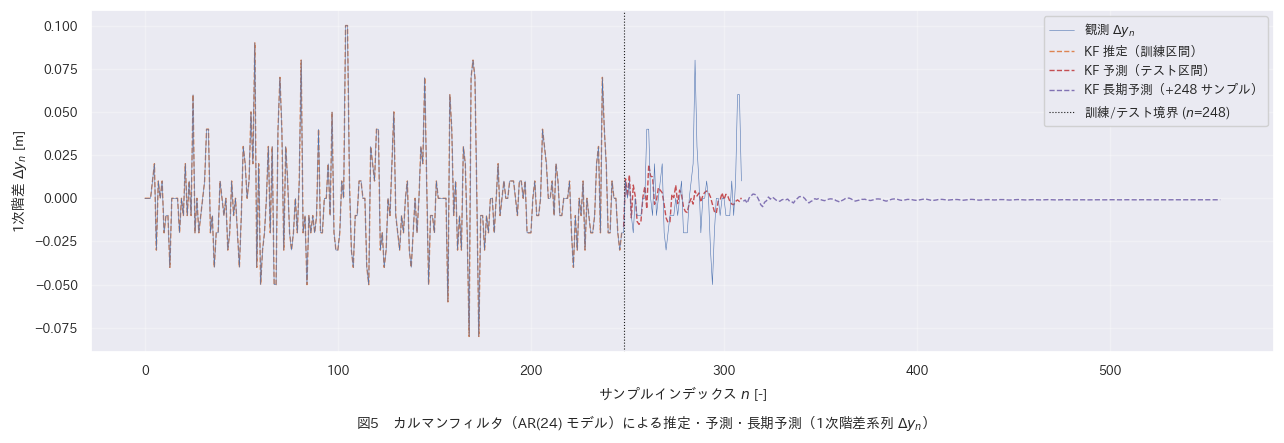

In [22]:
# ── 図5: 階差系列の推定・予測・長期予測 ──
idx_train = np.arange(ntrain)
idx_test  = np.arange(ntrain, ntrain + len(dy_test))
idx_long  = np.arange(ntrain + len(dy_test),
                      ntrain + len(dy_test) + N_LONG)

fig, ax = plt.subplots(figsize=(13, 4.5))

ax.plot(np.arange(len(dy)), dy,
        lw=0.4, color="C0", label="観測 $\\Delta y_n$", zorder=3)
ax.plot(idx_train, dy_kf_fit,
        "--", lw=1.0, color="C1", label="KF 推定（訓練区間）")
ax.plot(idx_test, dy_kf_fore,
        "--", lw=1.0, color="C3", label="KF 予測（テスト区間）")
ax.plot(idx_long, dy_long,
        "--", lw=1.0, color="C4",
        label=f"KF 長期予測（+{N_LONG} サンプル）")

ax.axvline(ntrain, color="k", ls=":", lw=0.8, label=f"訓練/テスト境界 ($n$={ntrain})")
ax.set_xlabel("サンプルインデックス $n$ [-]")
ax.set_ylabel("1次階差 $\\Delta y_n$ [m]")
ax.legend(loc="upper right", framealpha=0.85)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.subplots_adjust(bottom=0.20)
fig.text(
    0.5, 0.02,
    f"図5　カルマンフィルタ（AR({popt}) モデル）による推定・予測・長期予測（1次階差系列 $\\Delta y_n$）",
    ha="center", va="bottom", fontsize=10
)
plt.show()

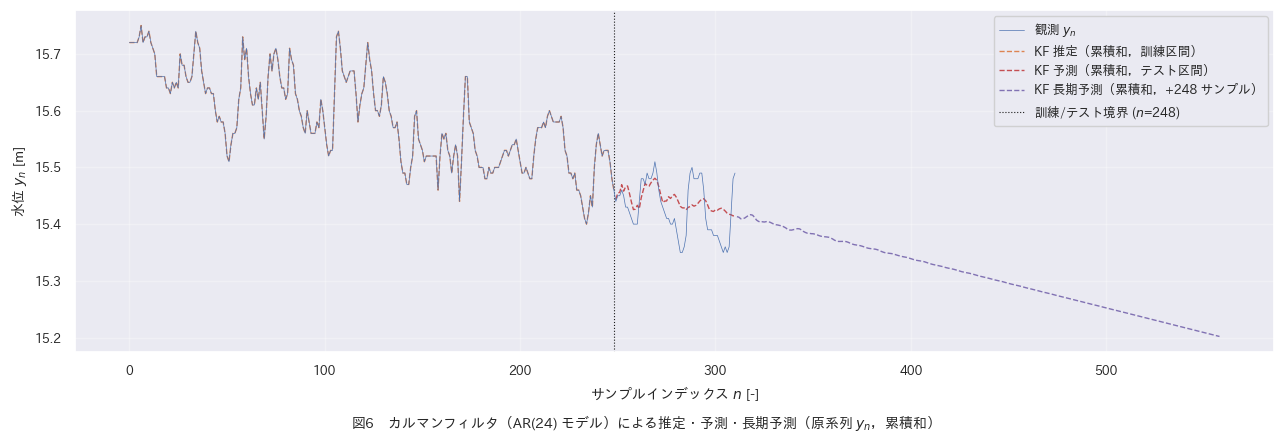

In [23]:
# ── 図6: 原系列への累積和による対応 ──
y0 = float(y[0])

# 訓練区間: y_0 を先頭に追加して cumsum
y_rec  = np.concatenate([[y0], y0 + np.cumsum(dy_kf_fit)])

# テスト区間: y_rec 末尾から継続
y_fore = y_rec[-1] + np.cumsum(dy_kf_fore)

# 長期予測: y_fore 末尾から継続
y_long_cum = y_fore[-1] + np.cumsum(dy_long)

idx_y_rec  = np.arange(ntrain + 1)
idx_y_fore = np.arange(ntrain + 1, ntrain + 1 + len(y_fore))
idx_y_long = np.arange(ntrain + 1 + len(y_fore),
                       ntrain + 1 + len(y_fore) + N_LONG)

fig, ax = plt.subplots(figsize=(13, 4.5))

ax.plot(np.arange(len(y)), y,
        lw=0.5, color="C0", label="観測 $y_n$", zorder=3)
ax.plot(idx_y_rec, y_rec,
        "--", lw=1.0, color="C1", label="KF 推定（累積和，訓練区間）")
ax.plot(idx_y_fore, y_fore,
        "--", lw=1.0, color="C3", label="KF 予測（累積和，テスト区間）")
ax.plot(idx_y_long, y_long_cum,
        "--", lw=1.0, color="C4",
        label=f"KF 長期予測（累積和，+{N_LONG} サンプル）")

ax.axvline(ntrain, color="k", ls=":", lw=0.8, label=f"訓練/テスト境界 ($n$={ntrain})")
ax.set_xlabel("サンプルインデックス $n$ [-]")
ax.set_ylabel("水位 $y_n$ [m]")
ax.legend(loc="upper right", framealpha=0.85)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.subplots_adjust(bottom=0.20)
fig.text(
    0.5, 0.02,
    f"図6　カルマンフィルタ（AR({popt}) モデル）による推定・予測・長期予測（原系列 $y_n$，累積和）",
    ha="center", va="bottom", fontsize=10
)
plt.show()

---
## 結果まとめ

| 項目 | 結果 |
|---|---|
| データ | 信濃川・長岡 水位（2025年7月20日〜8月1日） |
| 分析手法 | ADF 検定 → AR($p$) モデル（AIC 最小化）→ カルマンフィルタ |
| ADF 検定 $p$ 値 | 7.73874e-14（$\leq 0.05$ → 定常性確認） |
| AR 次数 $p$ | 24 |
| システムノイズ $Q=\sigma^2$ | 0.000612627777059 |
| 観測ノイズ $R$ | $0$（完全観測を仮定） |
| 長期予測 | 訓練区間長と等しい 248 サンプルを追加予測 |